# 1) About

## a. Purpose:
This notebook performs an exploratory analysis of the AMLSim dataset to understand the data before building a **temporal risk scoring model** for detecting structuring behavior.

We explore:
- Dataset structure, schema, and relationships between tables
- Data quality (missing values, duplicates, referential integrity)
- Numerical and categorical distributions
- Time coverage and transaction patterns
- Structural properties of the transaction network

## b. Business Context:
Financial institutions must detect **structuring**, where clients deliberately split transactions into smaller amounts to avoid regulatory reporting thresholds (e.g., €10,000). Traditional rule-based monitoring generates high volumes of false positives and fails to adapt to behavioral changes. This project explores whether supervised ML can improve detection.

## c. Analytical Philosophy:
Before building any model, we need to deeply understand the data: its shape, quality, limitations, and what signals might be available for detecting suspicious behavior. This EDA notebook is the foundation for all downstream feature engineering and modeling decisions.

## d. Dataset
The dataset is generated using **AMLSim**, an open-source synthetic financial transaction simulator designed for AML research.

| Dataset             | Description                          |
| ------------------- | ------------------------------------ |
| `accounts.csv`      | Bank account information             |
| `transactions.csv`  | Transaction records between accounts |
| `alerts.csv`        | Suspicious activity alerts           |

**Note:** AMLSim TimeStamp is a simulation step. This project assumes the timestamp represents the day index, with start date 2020-01-01.

## e. Outcome of This Notebook
By the end of this EDA, we will have:
- A clear understanding of data quality and completeness
- Insight into transaction distributions and account behavior patterns
- A validated data model (primary keys, relationships)
- A foundation for feature engineering decisions in the next notebook

# 2) Imports and Definitions

In [8]:
import pandas as pd
import numpy as np

from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option('display.expand_frame_repr', False)


In [ ]:
data_path = Path("../data/raw")

df_acc = pd.read_csv(data_path/ "accounts.csv") 
df_trx = pd.read_csv(data_path/ "transactions.csv") 
df_alerts = pd.read_csv(data_path/ "alerts.csv") 

# Handling TimeStamps
start_date = pd.Timestamp("2020-01-01")
df_trx["date"] = start_date + pd.to_timedelta(df_trx["TIMESTAMP"], unit="D")
df_alerts["date"] = start_date + pd.to_timedelta(df_alerts["TIMESTAMP"], unit="D")

df_alerts["datetime"] = pd.to_datetime(df_alerts["date"])
df_trx["datetime"] = pd.to_datetime(df_trx["date"])

# Creating a container for easier access
datasets = {
    "accounts": df_acc,
    "transactions": df_trx,
    "alerts": df_alerts,

}


In [14]:
datasets.keys()


dict_keys(['accounts', 'transactions', 'alerts'])

# 3) Data Overview

## 3.a General Overview

No nulls. No duplicates.

In [ ]:
for name, df in datasets.items():
    
    print(f"Dataset: {name}")
    print("-" * 50)    
    print("Shape:")
    print(df.shape)
    print()
    
    print("Info:")
    df.info()
    print()
    
    print("Head:")
    print(df.head())
    print()
    
    print("Null values:")
    print(df.isnull().sum())
    print()
    
    print("Duplicate rows:")
    print(df.duplicated().sum())
    print()
    
    print("=" * 70)
    print("\n")


Dataset: accounts
--------------------------------------------------
Shape:
(10000, 7)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ACCOUNT_ID      10000 non-null  int64  
 1   CUSTOMER_ID     10000 non-null  str    
 2   INIT_BALANCE    10000 non-null  float64
 3   COUNTRY         10000 non-null  str    
 4   ACCOUNT_TYPE    10000 non-null  str    
 5   IS_FRAUD        10000 non-null  bool   
 6   TX_BEHAVIOR_ID  10000 non-null  int64  
dtypes: bool(1), float64(1), int64(2), str(3)
memory usage: 565.5 KB

Head:
   ACCOUNT_ID CUSTOMER_ID  INIT_BALANCE COUNTRY ACCOUNT_TYPE  IS_FRAUD  TX_BEHAVIOR_ID
0           0         C_0        184.44      US            I     False               1
1           1         C_1        175.80      US            I     False               1
2           2         C_2        142.06      US            I     Fal

## 3.b Deeper Look

### Accounts

- How many customers, how many accounts? -> 10k both.

- client id - account id: is it one to many or one to many mapping? -> Yes.

- Account types? -> Only individuals

- Can one client have both fraud and nonfraud? -> No.

In [28]:
print("\n1. General Distribution:")

# Col distribution
print('\na. Col Distributions')
for col in df_acc.columns:
    print(f"Number of distinct {col}: {df_acc[col].nunique()}, Unique values: {df_acc[col].unique()}")
    print()

# Account Id - ClientId Relationship
print('\nb. Account-Client Relationship: Is there a one-to-one relationship between ACCOUNT_ID and CUSTOMER_ID?')
if (df_acc["CUSTOMER_ID"] == "C_" + df_acc["ACCOUNT_ID"].astype(str)).all():
    print("✅ Confirmed: 1:1 mapping between CUSTOMER_ID and ACCOUNT_ID (pattern: C_{ACCOUNT_ID})")
else:
    print("❌ Mismatch found between CUSTOMER_ID and ACCOUNT_ID")

print('\nc. Fraud Inspection: Can a client be both fraud and non-fraud?')
df_acc.groupby(
    ['CUSTOMER_ID', 'ACCOUNT_ID']
)['IS_FRAUD'].nunique().reset_index(name='UniqueValues').where(lambda x: x['UniqueValues'] > 1).query("UniqueValues > 1")



1. General Distribution:

a. Col Distributions
Number of distinct ACCOUNT_ID: 10000, Unique values: [   0    1    2 ... 9997 9998 9999]

Number of distinct CUSTOMER_ID: 10000, Unique values: <ArrowStringArray>
[   'C_0',    'C_1',    'C_2',    'C_3',    'C_4',    'C_5',    'C_6',
    'C_7',    'C_8',    'C_9',
 ...
 'C_9990', 'C_9991', 'C_9992', 'C_9993', 'C_9994', 'C_9995', 'C_9996',
 'C_9997', 'C_9998', 'C_9999']
Length: 10000, dtype: str

Number of distinct INIT_BALANCE: 8818, Unique values: [184.44 175.8  142.06 ... 260.85 323.79 317.65]

Number of distinct COUNTRY: 1, Unique values: <ArrowStringArray>
['US']
Length: 1, dtype: str

Number of distinct ACCOUNT_TYPE: 1, Unique values: <ArrowStringArray>
['I']
Length: 1, dtype: str

Number of distinct IS_FRAUD: 2, Unique values: [False  True]

Number of distinct TX_BEHAVIOR_ID: 5, Unique values: [1 2 3 4 5]


b. Account-Client Relationship: Is there a one-to-one relationship between ACCOUNT_ID and CUSTOMER_ID?
✅ Confirmed: 1:1 mapping

,CUSTOMER_ID,ACCOUNT_ID,UniqueValues



### Transactions


- Is transactionid primary key? -> Yes

- Can a transaction be both fraudulent and non-fraudulent? -> No

- Are all receivers and senders our clients? -> Yes

- Alerts are client level or trx level?

- Trx date interval? -> 2020-01-01 00:00:00, 2020-07-18 

- Trx country -> US only

In [44]:
print('\n1. General Distribution:')

print('\na. Col Distributions')
for col in df_acc.columns:
    print(f"\nNumber of distinct {col}: {df_acc[col].nunique()}, Unique values: {df_acc[col].unique()}")
    print()

print('\nb Primary Key Validation for TX_ID')
if df_trx["TX_ID"].is_unique and df_trx["TX_ID"].isnull().sum() == 0:
    print("\n✅ TX_ID is a valid primary key (unique, no nulls)")
else:
    print("❌ TX_ID is NOT a valid primary key")
    print(f"   Duplicates: {df_trx['TX_ID'].duplicated().sum()}")
    print(f"   Nulls: {df_trx['TX_ID'].isnull().sum()}")
print()

print("\nCan a transaction be both fraud and non-fraud?")

fraud_mix = df_trx.groupby("TX_ID")["IS_FRAUD"].nunique()

if (fraud_mix == 1).all():
    print("\n✅ No — each transaction has exactly one fraud label")
else:
    count = (fraud_mix > 1).sum()
    print(f"\n ❌ Yes — {count} transactions have both fraud and non-fraud labels")


print(f"   Are all senders and receivers in the accounts dataset?")
sender_accounts = set(df_trx['SENDER_ACCOUNT_ID'].unique())
receiver_accounts = set(df_trx['RECEIVER_ACCOUNT_ID'].unique())
account_ids = set(df_acc['ACCOUNT_ID'].unique())
missing_senders = sender_accounts - account_ids
missing_receivers = receiver_accounts - account_ids
if missing_senders == set() and missing_receivers == set():
    print("\n✅ All sender and receiver accounts are present in the accounts dataset.")
else:
    print("❌ Some sender or receiver accounts are missing in the accounts dataset.")
print()

print(f"   Max and Min Transaction Dates: {df_trx['date'].min()}, {df_trx['date'].max()}")



1. General Distribution:

a. Col Distributions

Number of distinct ACCOUNT_ID: 10000, Unique values: [   0    1    2 ... 9997 9998 9999]


Number of distinct CUSTOMER_ID: 10000, Unique values: <ArrowStringArray>
[   'C_0',    'C_1',    'C_2',    'C_3',    'C_4',    'C_5',    'C_6',
    'C_7',    'C_8',    'C_9',
 ...
 'C_9990', 'C_9991', 'C_9992', 'C_9993', 'C_9994', 'C_9995', 'C_9996',
 'C_9997', 'C_9998', 'C_9999']
Length: 10000, dtype: str


Number of distinct INIT_BALANCE: 8818, Unique values: [184.44 175.8  142.06 ... 260.85 323.79 317.65]


Number of distinct COUNTRY: 1, Unique values: <ArrowStringArray>
['US']
Length: 1, dtype: str


Number of distinct ACCOUNT_TYPE: 1, Unique values: <ArrowStringArray>
['I']
Length: 1, dtype: str


Number of distinct IS_FRAUD: 2, Unique values: [False  True]


Number of distinct TX_BEHAVIOR_ID: 5, Unique values: [1 2 3 4 5]


b Primary Key Validation for TX_ID

✅ TX_ID is a valid primary key (unique, no nulls)


Can a transaction be both fraud 

### Alerts



- One alert id can be associated with multiple transaction ids: 1:* relationship between AlertId and TransactionId

- All transactionids in the alert dataset is fraudulent

- Max and min dates in Alerts dataset 2020-01-01 - 2020-07-18

In [48]:
print('\n1. General Distribution:')

print('\na. Col Distributions')
for col in df_alerts.columns:
    print(f"\nNumber of distinct {col}: {df_alerts[col].nunique()}, Unique values: {df_alerts[col].unique()}")
    print()


print(f"   Do all transactions in alert exist in the transactions dataset? {df_alerts['TX_ID'].isin(df_trx['TX_ID']).all()}")

print(f"\n max and min dates in alerts: {df_alerts['date'].min()} - {df_alerts['date'].max()}")



1. General Distribution:

a. Col Distributions

Number of distinct ALERT_ID: 391, Unique values: [193 377 189 130 183 267 176 170   8 202 260 346 115 374 317  41 179  39
  61  32  14 323 174 166 356 100 242  88 363  68 138 145 330 302 387 351
  79 322 134 326 342  66 339 258  82  75 192 241 350 284 268 369 150 239
 380 257 123  25 252  59 190 282 313 151  87 365 329 214  73   1 230 210
 386  54 299 102 160 114  20  43 295  24 185 249 296  37 218 235 216 291
 336 196 245  97 237 389 248  91  42 318 273 304 111 355 132 398 104 259
 379 213 340 327  52 315  40 225 122  58 357  30 343 233 352 382 121 359
 226 393 238 141 396 286  10 376 178 362 131  51 246  12 142 287 147  48
  78 103 109 278 305  96 149  55 154  83 310  29 269 117 277 112  89 227
  22 275  81  57 345 129 152 319 181 347 146  84 331 271   7 110 392 324
  70 349 308 274 194  17  46 200  85 270  11 165  31 328  34  56  99  33
  71 198 203 229 301 128 397  62 255  28 364 263 265 169 254 378 370  13
 262  45 101 236 383 279  

##### AlertId - Transactions 

What is the pattern in same AlertIds? 

- Seems like for fan_in alerts, transactions for the same receiver get the same AlertI -> Yes.

- Seems like for cycle alerts, transactions with the same transaction amount gets the same AlertId -> No.


In [175]:
df_alerts.sort_values("ALERT_ID").head(50)

# Does all fan_in alerts get the same alert_id for the same receiver id?

df_alerts[df_alerts["ALERT_TYPE"] == "fan_in"].groupby("ALERT_ID")["RECEIVER_ACCOUNT_ID"].nunique().reset_index(name='UniqueReceivers').query("UniqueReceivers > 1")


,ALERT_ID,UniqueReceivers


# 4) Distributions

## Transaction Amount

The distribution of transaction amounts is highly right-skewed, with the majority of transactions concentrated at relatively low values and a small number of transactions occurring at substantially higher amounts. To improve interpretability, the amounts were log-transformed using (log10(x + 1)) which compresses large values while preserving the relative differences across orders of magnitude.

The median transaction amount (P50) is approximately 157, indicating that half of all transactions occur below this value. The 90th percentile (P90) occurs at approximately 548, suggesting that most transactions remain within a relatively moderate range. However, the 99th percentile (P99) increases sharply to approximately 1.85 million, highlighting the presence of extremely large transactions that form the long tail of the distribution.

This heavy-tailed pattern is typical in financial transaction datasets, where a large volume of small transactions is accompanied by a relatively small number of high-value transfers. The logarithmic scaling enables visualization of these multiple orders of magnitude within a single distribution plot.

- max transaction amount:  21474836.47 min transaction amount:  0.0

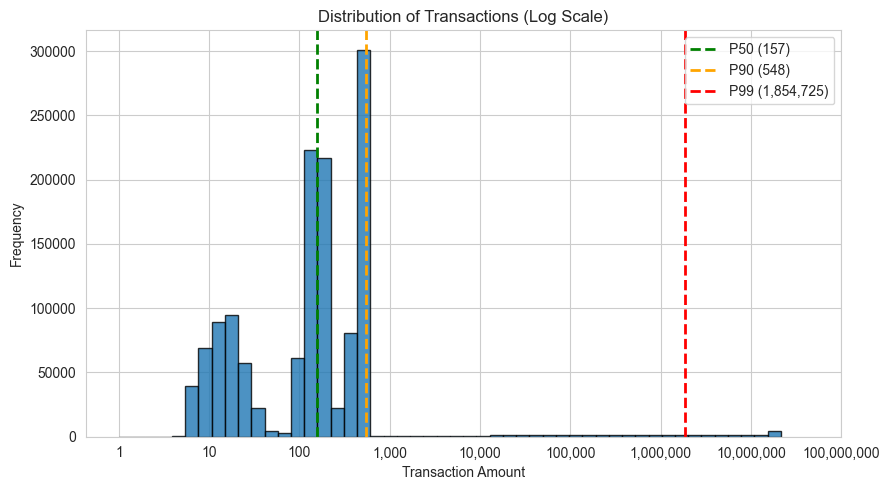

max transaction amount:  21474836.47 min transaction amount:  0.0


In [177]:
# Log transform - EXTREMELY SKEWED DISTRIBUTION - +1 ensures zero values are handled safely and improves visualization
log_amount = np.log10(df_trx["TX_AMOUNT"] + 1)

plt.figure(figsize=(9,5))
plt.hist(log_amount, bins=50, edgecolor="black", alpha=0.8)

max_log = int(np.ceil(log_amount.max()))
ticks = np.arange(0, max_log + 1)
tick_labels = [f"{int(10**t):,}" for t in ticks]

plt.xticks(ticks, tick_labels)

p50 = np.percentile(log_amount, 50)
p90 = np.percentile(log_amount, 90)
p99 = np.percentile(log_amount, 99)

# Convert percentiles back to real values
p50_real = 10**p50 - 1
p90_real = 10**p90 - 1
p99_real = 10**p99 - 1

# Plot percentile lines
plt.axvline(p50, color="green", linestyle="--", linewidth=2,
            label=f"P50 ({p50_real:,.0f})")

plt.axvline(p90, color="orange", linestyle="--", linewidth=2,
            label=f"P90 ({p90_real:,.0f})")

plt.axvline(p99, color="red", linestyle="--", linewidth=2,
            label=f"P99 ({p99_real:,.0f})")

# Labels
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Transactions (Log Scale)")

plt.legend()
plt.tight_layout()

plt.show()

print('max transaction amount: ', df_trx["TX_AMOUNT"].max(), 'min transaction amount: ', df_trx["TX_AMOUNT"].min())


## Account Balances

Account balances are relatively evenly distributed between 100 and 600, with most accounts concentrated between 100 and 400. Compared to transaction amounts, balances show much less skewness, indicating a more controlled range of values.

- max balance:  599.6 min balance:  100.0

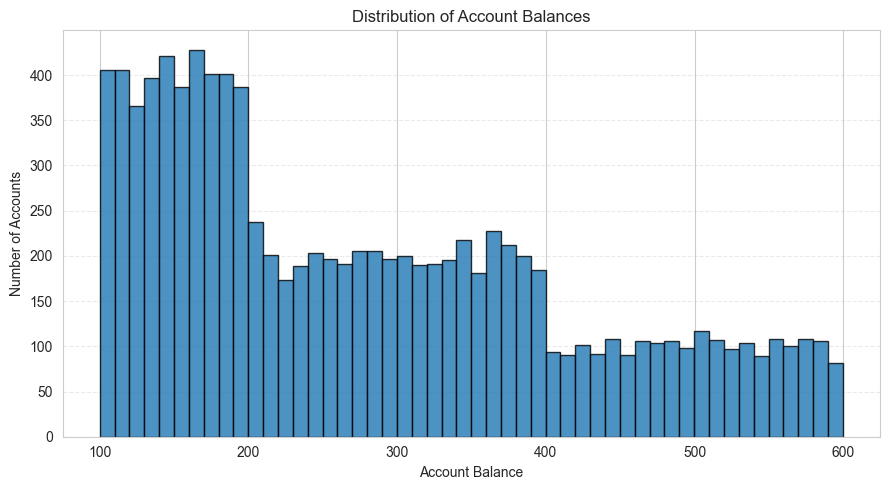

max balance:  599.6 min balance:  100.0


In [178]:
plt.figure(figsize=(9,5))

plt.hist(
    df_acc["INIT_BALANCE"],
    bins=50,
    edgecolor="black",
    alpha=0.8
)

plt.xlabel("Account Balance")
plt.ylabel("Number of Accounts")
plt.title("Distribution of Account Balances")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


print('max balance: ', df_acc["INIT_BALANCE"].max(), 'min balance: ', df_acc["INIT_BALANCE"].min())


## Transaction Activity

- Transaction activity varies across accounts, with most accounts performing a relatively small number of transactions while a smaller subset of accounts exhibits higher activity levels. This uneven activity distribution is typical in transaction networks, where financial activity is often concentrated among a subset of participants.

- The maximum number of incoming transactions for an account is significantly higher than the maximum number of outgoing transactions. This indicates that incoming and outgoing activity is unevenly distributed across accounts, with some accounts receiving far more transactions than others.

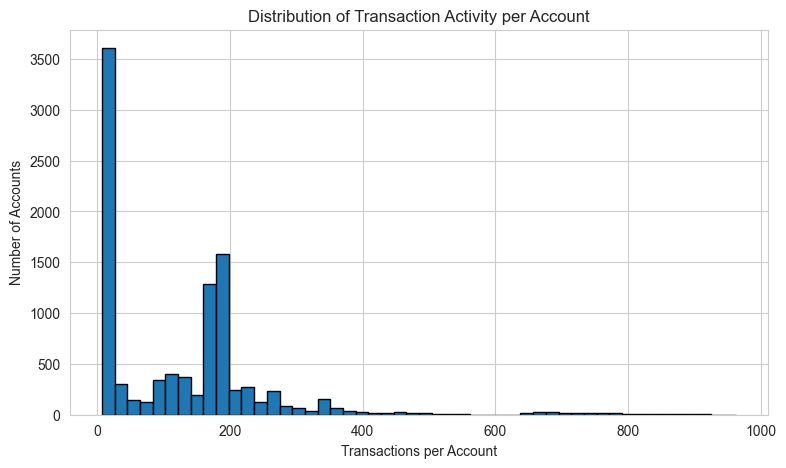

max transfers sent per account:  963 min transactions per account:  7


In [179]:
trx_per_sender = df_trx.groupby("SENDER_ACCOUNT_ID").size()

plt.figure(figsize=(9,5))
plt.hist(trx_per_sender, bins=50, edgecolor="black")

plt.xlabel("Transactions per Account")
plt.ylabel("Number of Accounts")
plt.title("Distribution of Transaction Activity per Account")

plt.show()

print('max transfers sent per account: ', trx_per_sender.max(), 'min transactions per account: ', trx_per_sender.min())


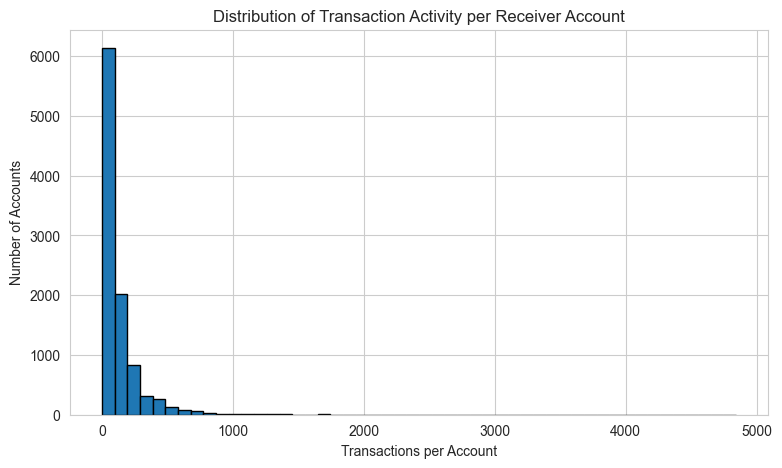

max transfers received per account:  4843 min transactions received per account:  1


In [180]:
trx_per_sender = df_trx.groupby("RECEIVER_ACCOUNT_ID").size()

plt.figure(figsize=(9,5))
plt.hist(trx_per_sender, bins=50, edgecolor="black")

plt.xlabel("Transactions per Account")
plt.ylabel("Number of Accounts")
plt.title("Distribution of Transaction Activity per Receiver Account")

plt.show()

print('max transfers received per account: ', trx_per_sender.max(), 'min transactions received per account: ', trx_per_sender.min())


In [181]:
print(df_trx["RECEIVER_ACCOUNT_ID"].value_counts().head())

print(df_trx["SENDER_ACCOUNT_ID"].value_counts().head())


RECEIVER_ACCOUNT_ID
9982    4843
9993    3948
9971    3420
9983    2850
9998    2767
Name: count, dtype: int64
SENDER_ACCOUNT_ID
9799    963
9797    962
9785    922
9793    921
9790    921
Name: count, dtype: int64


### Incoming vs Outgoing Transaction Activity

The log–log scatter plot of incoming and outgoing transactions highlights heterogeneous participation across accounts.  Many accounts lie either above or below the diagonal reference line, indicating that some accounts receive substantially more transactions than they send, while others send more than they receive, indicating asymmetry in account-level transaction activity.

In [182]:
sent_per_account = df_trx.groupby("SENDER_ACCOUNT_ID").size()
received_per_account = df_trx.groupby("RECEIVER_ACCOUNT_ID").size()

activity = pd.DataFrame({
    "sent": sent_per_account,
    "received": received_per_account
}).fillna(0)


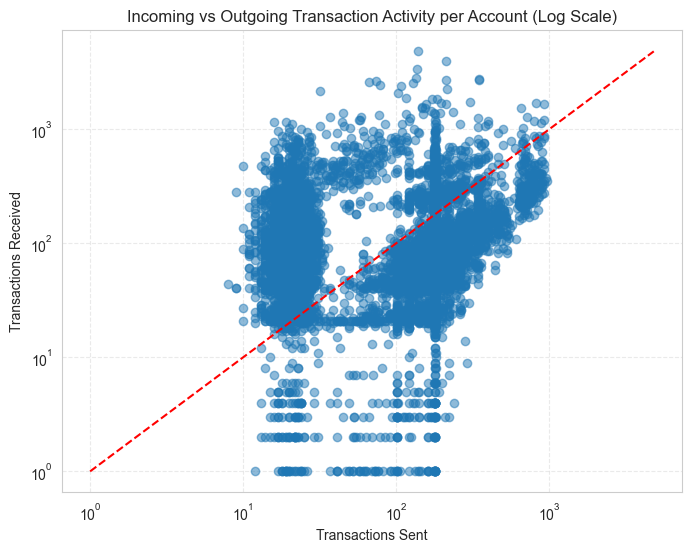

In [183]:
plt.figure(figsize=(8,6))

plt.scatter(
    activity["sent"] + 1,
    activity["received"] + 1,
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Transactions Sent")
plt.ylabel("Transactions Received")
plt.title("Incoming vs Outgoing Transaction Activity per Account (Log Scale)")

plt.grid(True, linestyle="--", alpha=0.4)

max_val = max(activity["sent"].max(), activity["received"].max())

plt.plot([1, max_val], [1, max_val], color="red", linestyle="--")

plt.show()


## Alert Distribution 

A balanced distribution between Fan-in and Cycle Alert Types.

No clear trend is observed in alerts generated over time.

In [184]:
df_alerts.head()


,ALERT_ID,ALERT_TYPE,IS_FRAUD,TX_ID,SENDER_ACCOUNT_ID,RECEIVER_ACCOUNT_ID,TX_TYPE,TX_AMOUNT,TIMESTAMP,date,datetime
0,193,fan_in,True,82,6976,9739,TRANSFER,4.85,0,2020-01-01,2020-01-01
1,377,cycle,True,949,5776,2570,TRANSFER,10.27,0,2020-01-01,2020-01-01
2,189,fan_in,True,6280,9999,9530,TRANSFER,2.74,1,2020-01-02,2020-01-02
3,377,cycle,True,7999,1089,7352,TRANSFER,10.27,1,2020-01-02,2020-01-02
4,130,fan_in,True,12975,7025,9708,TRANSFER,3.53,2,2020-01-03,2020-01-03


ALERT_TYPE
cycle     936
fan_in    783
Name: count, dtype: int64


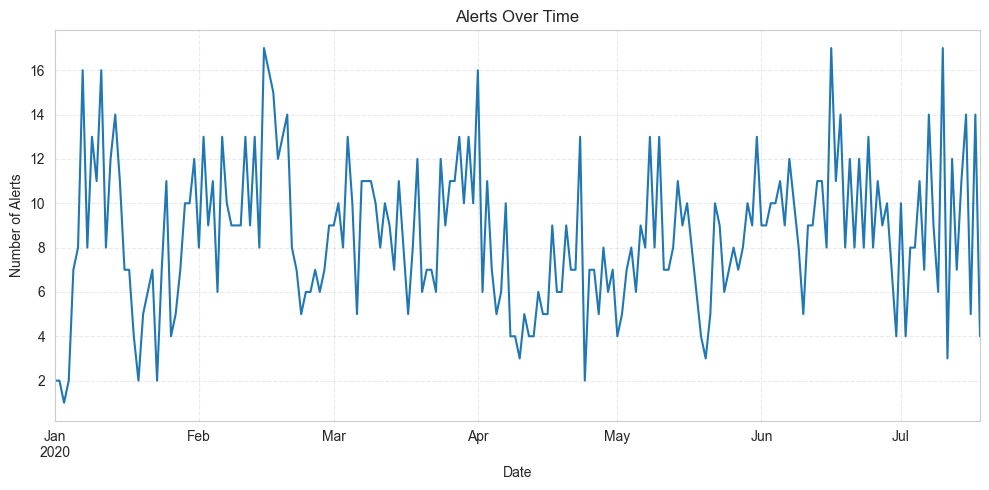

In [185]:
# Alert type
print(df_alerts['ALERT_TYPE'].value_counts())

# Alerts Over Time

plt.figure(figsize=(10,5))
df_alerts.set_index("datetime").resample("D").size().plot()
plt.title("Alerts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Alerts")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


## Transactions Over Time

- No clear trend.

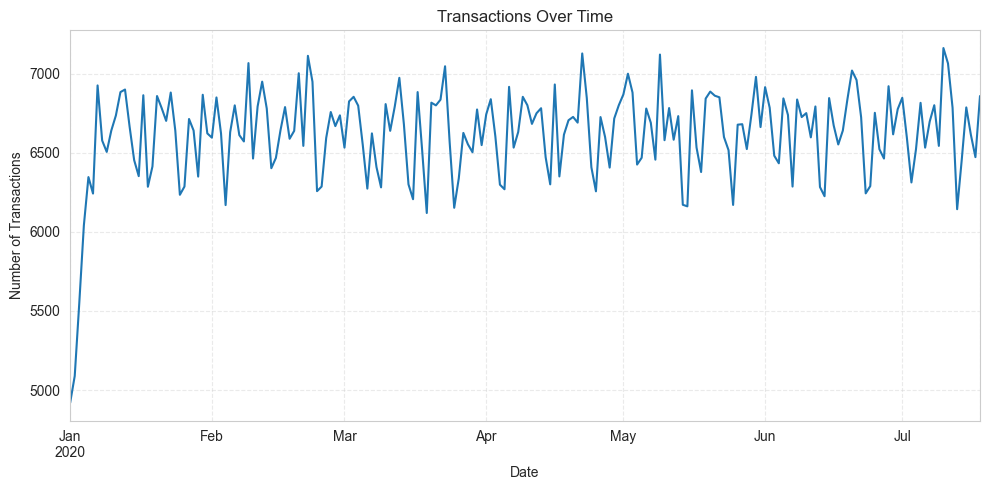

In [186]:
plt.figure(figsize=(10,5))
df_trx.set_index("datetime").resample("D").size().plot()
plt.title("Transactions Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


## Network Size & Density

Network density metric measures how connected the transaction network is by comparing the number of existing connections (transactions) to the maximum number of possible connections between nodes.

A density of 0.013 (≈1.3%) indicates that only a small fraction of all possible connections actually occur in the network. This suggests the transaction graph is sparse, meaning most nodes interact with only a limited number of other nodes rather than forming a highly interconnected network.

Sparse networks are common in real-world transaction systems because entities typically transact with a small subset of participants rather than with everyone in the network.

In [187]:
nodes = set(df_trx["SENDER_ACCOUNT_ID"]).union(
    set(df_trx["RECEIVER_ACCOUNT_ID"])
)

edges = df_trx.shape[0]

print("Accounts:", len(nodes))
print("Transactions:", edges)


Accounts: 9999
Transactions: 1323234


In [ ]:
num_nodes = len(nodes)
num_edges = len(df_trx)

density = num_edges / (num_nodes * (num_nodes - 1))
print("Network density:", density)


Network density: 0.013236310628462327


# 5) Data Model - Relationships Between Tables

Identifier columns were examined to determine primary keys and relationships between tables. The ACCOUNT_ID column uniquely identifies accounts, while TX_ID uniquely identifies transactions. In the alerts table, TX_ID also uniquely identifies rows, indicating that each record corresponds to a transaction involved in an alert. The ALERT_ID column appears multiple times and therefore acts as a grouping identifier linking multiple transactions to the same alert event.

## Schema:

| Table | Key Column | Role | References |
|------|------|------|------|
| accounts | `ACCOUNT_ID` | Primary key | — |
| transactions | `TX_ID` | Primary key | — |
| transactions | `SENDER_ACCOUNT_ID` | Foreign key | accounts.ACCOUNT_ID |
| transactions | `RECEIVER_ACCOUNT_ID` | Foreign key | accounts.ACCOUNT_ID |
| alerts | `TX_ID` | Primary key | transactions.TX_ID |
| alerts | `ALERT_ID` | Group identifier | groups multiple transactions |

In [188]:
def check_primary_key(df, col):
    print(f"Checking primary key candidate: {col}")
    print(f"Missing values: {df[col].isnull().sum()}")
    print(f"Duplicate values: {df[col].duplicated().sum()}")
    print(f"Unique values: {df[col].nunique()} / {len(df)}")
    print("-" * 50)

check_primary_key(df_acc, "ACCOUNT_ID")
check_primary_key(df_trx, "TX_ID")
check_primary_key(df_alerts, "ALERT_ID")
check_primary_key(df_alerts, "TX_ID")


Checking primary key candidate: ACCOUNT_ID
Missing values: 0
Duplicate values: 0
Unique values: 10000 / 10000
--------------------------------------------------
Checking primary key candidate: TX_ID
Missing values: 0
Duplicate values: 0
Unique values: 1323234 / 1323234
--------------------------------------------------
Checking primary key candidate: ALERT_ID
Missing values: 0
Duplicate values: 1328
Unique values: 391 / 1719
--------------------------------------------------
Checking primary key candidate: TX_ID
Missing values: 0
Duplicate values: 0
Unique values: 1719 / 1719
--------------------------------------------------


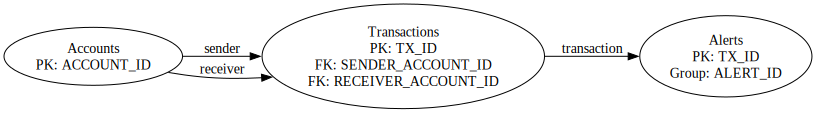

In [189]:
from graphviz import Digraph

schema = Digraph(graph_attr={"rankdir": "LR"})

schema.node("accounts", "Accounts\nPK: ACCOUNT_ID")

schema.node(
    "transactions",
    "Transactions\nPK: TX_ID\nFK: SENDER_ACCOUNT_ID\nFK: RECEIVER_ACCOUNT_ID"
)

schema.node(
    "alerts",
    "Alerts\nPK: TX_ID\nGroup: ALERT_ID"
)

schema.edge("accounts", "transactions", label="sender")
schema.edge("accounts", "transactions", label="receiver")
schema.edge("transactions", "alerts", label="transaction")

schema


In [190]:
print("All sender accounts exist in accounts:",
      df_trx["SENDER_ACCOUNT_ID"].isin(df_acc["ACCOUNT_ID"]).all())

print("All receiver accounts exist in accounts:",
      df_trx["RECEIVER_ACCOUNT_ID"].isin(df_acc["ACCOUNT_ID"]).all())

print("All alert transaction IDs exist in transactions:",
      df_alerts["TX_ID"].isin(df_trx["TX_ID"]).all())


All sender accounts exist in accounts: True
All receiver accounts exist in accounts: True
All alert transaction IDs exist in transactions: True


# 6) Final EDA Summary

This exploratory analysis examined the structure, quality, and statistical properties of the AMLSim dataset. The dataset is structurally consistent, with no missing values or exact duplicate rows in the loaded tables. Transaction amounts show a strongly right-skewed distribution, while account balances are more bounded and evenly distributed. Transaction activity varies substantially across accounts, and alerts group multiple transactions under shared alert identifiers. Overall, the dataset is well-structured for subsequent behavioral analysis.


- No missing values or exact duplicate rows were observed in the loaded tables.

- All clients are based in the US and belong to the individual account type.

- There is a 1:1 mapping between `CUSTOMER_ID` and `ACCOUNT_ID`, following the pattern `CUSTOMER_ID = "C_" + ACCOUNT_ID`.

- Each client is associated with a single fraud label.

- Transaction history spans from 2020-01-01 to 2020-07-18.

- `TX_ID` uniquely identifies transactions.

- Each transaction is associated with a single fraud label.

- All sender and receiver accounts in the transactions table are present in the accounts table.

- Alerts are transaction-level.

- A single `ALERT_ID` can be associated with multiple transactions, indicating a one-to-many relationship between alerts and transactions.

- All transactions present in the alerts table are labeled as fraudulent.

- The alert data spans the same date range as the transaction data: 2020-01-01 to 2020-07-18.
